# Linear Regression Practicle Implementation

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing # dataset which specifies california housing data, it is available in sklearn, we can load it directly from sklearn

In [23]:
df = fetch_california_housing() # load the california housing dataset
df

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 

In [26]:
dataset = pd.DataFrame(df.data)   # convert the data into a pandas dataframe for better visualization and analysis
dataset

,0,1,2,3,4,5,6,7
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [27]:
dataset.columns = df.feature_names  # assign the feature names to the dataframe columns
dataset.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [28]:
## Independent and Dependent Features
X = dataset
y = df.target

In [29]:
y

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,))

In [30]:
## train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

'''
X_train and Y_train will be used to train the model and X_test and y_test will be used to evaluate the model performance after training
'''

'\nX_train and Y_train will be used to train the model and X_test and y_test will be used to evaluate the model performance after training\n'

In [31]:
X_train

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
14196,3.2596,33.0,5.017657,1.006421,2300.0,3.691814,32.71,-117.03
8267,3.8125,49.0,4.473545,1.041005,1314.0,1.738095,33.77,-118.16
17445,4.1563,4.0,5.645833,0.985119,915.0,2.723214,34.66,-120.48
14265,1.9425,36.0,4.002817,1.033803,1418.0,3.994366,32.69,-117.11
2271,3.5542,43.0,6.268421,1.134211,874.0,2.300000,36.78,-119.80
...,...,...,...,...,...,...,...,...
11284,6.3700,35.0,6.129032,0.926267,658.0,3.032258,33.78,-117.96
11964,3.0500,33.0,6.868597,1.269488,1753.0,3.904232,34.02,-117.43
5390,2.9344,36.0,3.986717,1.079696,1756.0,3.332068,34.03,-118.38
860,5.7192,15.0,6.395349,1.067979,1777.0,3.178891,37.58,-121.96


In [35]:
## Standardizing the dataset
'''
Standardizing means scaling numeric features so they all have:

mean = 0
standard deviation = 1
That is, each value is transformed as:

x_scaled = (x - mean) / std
Why this matters
It makes features comparable when they have very different units or ranges
It helps many models train better and faster
It avoids one feature dominating because it has much larger values
'''
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()  # create an instance of the StandardScaler
X_train = scaler.fit_transform(X_train)  # fit the scaler to the training data and transform it
X_train

array([[-0.326196  ,  0.34849025, -0.17491646, ...,  0.05137609,
        -1.3728112 ,  1.27258656],
       [-0.03584338,  1.61811813, -0.40283542, ..., -0.11736222,
        -0.87669601,  0.70916212],
       [ 0.14470145, -1.95271028,  0.08821601, ..., -0.03227969,
        -0.46014647, -0.44760309],
       ...,
       [-0.49697313,  0.58654547, -0.60675918, ...,  0.02030568,
        -0.75500738,  0.59946887],
       [ 0.96545045, -1.07984112,  0.40217517, ...,  0.00707608,
         0.90651045, -1.18553953],
       [-0.68544764,  1.85617335, -0.85144571, ..., -0.08535429,
         0.99543676, -1.41489815]], shape=(16512, 8))

In [39]:
'''
Why use transform on X_test
fit_transform(X_train) computes the mean and standard deviation from the training data, then scales X_train.
transform(X_test) uses the same mean and std from the training data to scale X_test.
Why not fit_transform(X_test)?
fit_transform(X_test) would compute new scaling values from the test data.
That changes the feature scaling and makes the test set inconsistent with training.
It also leaks information from the test set into preprocessing.
Best practice
Use fit_transform only on training data.
Use transform on validation/test data.
'''
X_test = scaler.transform(X_test)  # transform the test data using the same scaler fitted on the training data
X_test

array([[   1.6812    ,   25.        ,    4.19220056, ...,    3.87743733,
          36.06      , -119.01      ],
       [   2.5313    ,   30.        ,    5.03938356, ...,    2.67979452,
          35.14      , -119.46      ],
       [   3.4801    ,   52.        ,    3.97715472, ...,    1.36033229,
          37.8       , -122.44      ],
       ...,
       [   9.2298    ,   25.        ,    7.23767606, ...,    2.79049296,
          37.31      , -122.05      ],
       [   2.785     ,   36.        ,    5.28902954, ...,    2.58860759,
          36.77      , -119.76      ],
       [   3.5521    ,   17.        ,    3.98883929, ...,    3.72991071,
          34.22      , -118.37      ]], shape=(4128, 8))

In [40]:
from sklearn.linear_model import LinearRegression
## cross validation -> technique to evaluate the performance of a model by splitting the data into multiple subsets and training/testing the model on different combinations of these subsets. It helps to get a more reliable estimate of the model's performance and reduces the risk of overfitting or underfitting.
from sklearn.model_selection import cross_val_score


In [46]:
regression = LinearRegression()  # create an instance of the LinearRegression model
regression.fit(X_train, y_train)  # fit the regression model to the training data
mse = cross_val_score(regression, X_train, y_train, scoring='neg_mean_squared_error', cv=10)  # perform cross validation on the training data with 10 folds, neg_mean_squared_error is used as the scoring metric to evaluate the model's performance, it returns negative values because cross_val_score expects a score where higher is better, but for mean squared error, lower is better, so it negates the values to fit this expectation.
mse

array([-0.46912055, -0.57023278, -0.52267997, -0.48319985, -0.54304536,
       -0.49879977, -0.47454501, -0.54283267, -0.54130712, -0.55059256])

In [44]:
np.mean(mse)  # calculate the mean of the negative mean squared error values to get an overall performance metric for the model across all folds of the cross validation.

np.float64(-0.519635564764504)

In [48]:
## prediction
reg_pred = regression.predict(X_test)  # use the trained regression model to make predictions on the test data
reg_pred

array([73.49053637, 75.50450955, 80.16995219, ..., 80.13998083,
       75.89436733, 74.62812135], shape=(4128,))

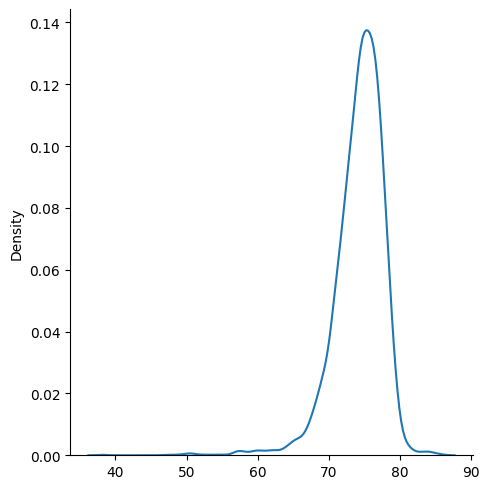

In [49]:
# Compare the predicted values with the actual target values, i.e. y_test, to evaluate the performance of the model on the unseen test data. This can be done using various metrics such as mean squared error, mean absolute error, R-squared, etc., depending on the specific requirements of the analysis.
import seaborn as sns
sns.displot(reg_pred - y_test, kind='kde')  # plot the distribution of the residuals (predicted values - actual values) to assess the model's performance and check for any patterns or biases in the predictions.  


In [52]:
from sklearn.metrics import r2_score
score = r2_score(y_test, reg_pred)  # calculate the R-squared score to evaluate the proportion of variance in the dependent variable that is predictable from the independent variables, it provides a measure of how well the regression model fits the data.
score

-4214.291797132178